# 06 · ML Prediction — Confusion Matrix, Tuning, Business-Robustness

Trains a fraud classifier end-to-end and answers the questions a **product lead** actually has:

1. *Does the model beat a baseline?* — PR-AUC and ROC-AUC on validation.
2. *Where should we tune?* — small `RandomizedSearchCV` over XGBoost, scored by **PR-AUC** (not accuracy — accuracy is meaningless when 0.17% of rows are positive).
3. *Where do we operate?* — threshold chosen to **maximise net $ saved**, not F1 or 0.5.
4. *Is it robust?* — calibration plot, sensitivity to the FP-cost assumption, and segment-level PR-AUC across hour and amount buckets.

**Cost model** (assumed, editable at top of notebook):
- false positive → analyst review costs `$FP_COST`
- true positive  → save the transaction amount minus review cost
- false negative → lose the full transaction amount

This is what drives the operating threshold below.

In [1]:
# project-root bootstrap — portable across VS Code / Jupyter / CLI
import os
from pathlib import Path
_p = Path.cwd()
while not (_p / 'config' / 'config.yaml').exists() and _p != _p.parent:
    _p = _p.parent
os.chdir(_p)
print('working dir:', Path.cwd())

working dir: /Users/asfalanoi/app_2026/fraud_detection


In [2]:
import warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import (
    average_precision_score, roc_auc_score, confusion_matrix,
    precision_recall_curve, roc_curve, f1_score,
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from xgboost import XGBClassifier

from fraud.io import read_parquet, save_pickle
from fraud.preprocess import build_preprocessor, V_COLS
from fraud.modeling import make_model
from fraud.evaluate import ml_metrics
from fraud.costs import confusion_costs, net_saved, optimal_threshold

warnings.filterwarnings('ignore', category=UserWarning)
plt.rcParams.update({'figure.facecolor':'white','axes.spines.top':False,
                     'axes.spines.right':False,'axes.titleweight':'bold'})
FIG       = Path('reports/figures'); FIG.mkdir(parents=True, exist_ok=True)
MODEL_DIR = Path('models');          MODEL_DIR.mkdir(parents=True, exist_ok=True)

FEATURES = ['Time', 'Amount'] + V_COLS
FP_COST  = 4.0    # business assumption — we stress-test this in §7
RANDOM_STATE = 0

In [3]:
train = read_parquet('data/processed/train.parquet')
valid = read_parquet('data/processed/valid.parquet')
test  = read_parquet('data/processed/test.parquet')

pre = build_preprocessor()
X_train = pre.fit_transform(train[FEATURES])
X_valid = pre.transform(valid[FEATURES])
X_test  = pre.transform(test[FEATURES])
y_train, y_valid, y_test = train.Class.values, valid.Class.values, test.Class.values
amt_valid, amt_test = valid.Amount.values, test.Amount.values

print(f"shapes  train={X_train.shape}  valid={X_valid.shape}  test={X_test.shape}")
print(f"positives train:{y_train.sum()}  valid:{y_valid.sum()}  test:{y_test.sum()}")

shapes  train=(227845, 32)  valid=(28481, 32)  test=(28481, 32)
positives train:394  valid:49  test:49


## 1 · Baseline vs XGBoost

Start with **balanced logistic regression** (cheap, interpretable, fair) and then **XGBoost with `scale_pos_weight`** (the workhorse for imbalanced tabular). Scored on validation by PR-AUC and ROC-AUC.

In [4]:
spw = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

logreg   = make_model('logreg').fit(X_train, y_train)
xgb_base = make_model('xgb', scale_pos_weight=spw).fit(X_train, y_train)

def report(name, model):
    p = model.predict_proba(X_valid)[:, 1]
    return {'model': name,
            'pr_auc':  round(average_precision_score(y_valid, p), 4),
            'roc_auc': round(roc_auc_score(y_valid, p), 4)}

pd.DataFrame([report('logreg-balanced', logreg),
              report('xgb-base',        xgb_base)])

,model,pr_auc,roc_auc
0,logreg-balanced,0.6730,0.9648
1,xgb-base,0.8565,0.9713


## 2 · Hyperparameter tuning (RandomizedSearchCV, PR-AUC)

A small principled search over XGBoost. We use **PR-AUC** as the scorer (`scoring='average_precision'`) because both ROC-AUC and accuracy reward correctly classifying the easy negative majority — useless when 0.17% of rows are positive.

`n_iter=8` × `cv=3` is intentionally modest — enough to see meaningful movement, fast enough to re-run during a review meeting.

In [5]:
param_dist = {
    'max_depth':        [3, 4, 5, 6, 7],
    'learning_rate':    [0.03, 0.05, 0.1],
    'n_estimators':     [200, 300, 500],
    'subsample':        [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0],
    'min_child_weight': [1, 5, 10],
}
search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=spw, eval_metric='aucpr',
                  tree_method='hist', n_jobs=-1, random_state=RANDOM_STATE),
    param_distributions=param_dist, n_iter=8,
    scoring='average_precision',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=1, verbose=0, random_state=RANDOM_STATE,
)
search.fit(X_train, y_train)
print('best PR-AUC (cv):', round(search.best_score_, 4))
print('best params     :', search.best_params_)

best PR-AUC (cv): 0.8541
best params     : {'subsample': 0.85, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.85}


## 3 · Calibrate the tuned model

A tuned XGB is sharp but its raw outputs are not probabilities. We wrap the frozen estimator in `CalibratedClassifierCV(method='isotonic')` fit on **validation** — necessary because §4 picks a threshold on probabilities and §7 stress-tests *dollar* outcomes that only make sense if scores are calibrated.

In [6]:
best_xgb = search.best_estimator_  # already fit on X_train
cal = CalibratedClassifierCV(FrozenEstimator(best_xgb), method='isotonic').fit(X_valid, y_valid)
proba_valid = cal.predict_proba(X_valid)[:, 1]
proba_test  = cal.predict_proba(X_test)[:, 1]
print(f"valid PR-AUC (calibrated): {average_precision_score(y_valid, proba_valid):.4f}")
print(f"test  PR-AUC (calibrated): {average_precision_score(y_test,  proba_test):.4f}")

valid PR-AUC (calibrated): 0.8591
test  PR-AUC (calibrated): 0.8855


## 4 · Pick the operating threshold (business-driven)

Default ML uses 0.5 or the F1-maximising threshold. Neither is what a fraud team wants. We define:

> **net $ saved (t)** = $ caught on TP − ($4 × number of FP) − $ lost on FN already lost.

We sweep candidates on **validation** and pick the one maximising net $. The sweep also shows F1-optimal and default 0.5 for reference.

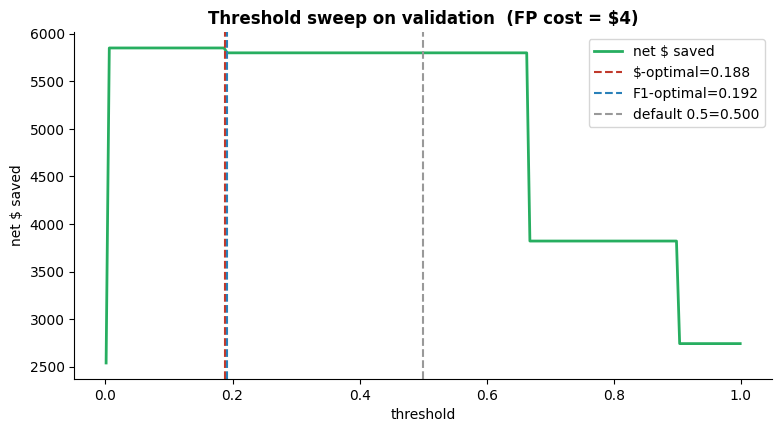

$-optimal threshold = 0.1875  →  net $5,850.27 on validation


In [7]:
ts  = np.linspace(0.001, 0.999, 200)
net = [net_saved(y_valid, proba_valid, amt_valid, t, fp_cost=FP_COST) for t in ts]
f1s = [f1_score(y_valid, (proba_valid >= t).astype(int), zero_division=0) for t in ts]
t_star, best_net = optimal_threshold(y_valid, proba_valid, amt_valid, fp_cost=FP_COST)
t_f1 = float(ts[int(np.argmax(f1s))])

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(ts, net, color='#27ae60', lw=2, label='net $ saved')
for tx, lbl, col in [(t_star, '$-optimal', '#c0392b'),
                     (t_f1,   'F1-optimal','#2980b9'),
                     (0.5,    'default 0.5','#999')]:
    ax.axvline(tx, color=col, ls='--', label=f"{lbl}={tx:.3f}")
ax.set(title=f'Threshold sweep on validation  (FP cost = ${FP_COST:.0f})',
       xlabel='threshold', ylabel='net $ saved')
ax.legend()
fig.savefig(FIG/'threshold_sweep.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"$-optimal threshold = {t_star:.4f}  →  net ${best_net:,.2f} on validation")

## 5 · Confusion matrices — three operating points

Same calibrated model, evaluated on **test**, at three thresholds. Each panel shows counts plus the **dollar consequences** (caught / missed / FP cost / net) — the single most useful artefact for a business stakeholder.

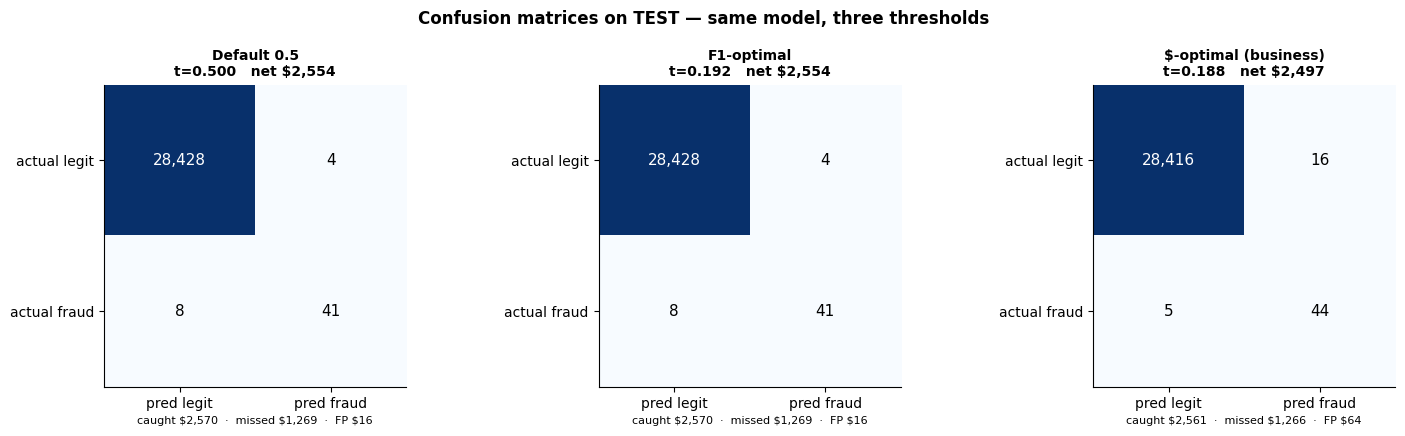

In [8]:
def cm_panel(ax, t, proba, y_true, amount, title):
    y_pred = (proba >= t).astype(int)
    cm    = confusion_matrix(y_true, y_pred, labels=[0, 1])
    costs = confusion_costs(y_true, y_pred, amount, fp_cost=FP_COST)
    ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0,1]); ax.set_xticklabels(['pred legit','pred fraud'])
    ax.set_yticks([0,1]); ax.set_yticklabels(['actual legit','actual fraud'])
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, f"{v:,}", ha='center', va='center',
                fontsize=11, color='white' if v > cm.max()/2 else 'black')
    ax.set_title(f"{title}\nt={t:.3f}   net ${costs['net_saved_$']:,.0f}", fontsize=10)
    ax.set_xlabel(f"caught ${costs['fraud_caught_$']:,.0f}  ·  missed ${costs['fraud_missed_$']:,.0f}  ·  FP ${costs['fp_$']:,.0f}",
                  fontsize=8)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
cm_panel(axes[0], 0.5,    proba_test, y_test, amt_test, 'Default 0.5')
cm_panel(axes[1], t_f1,   proba_test, y_test, amt_test, 'F1-optimal')
cm_panel(axes[2], t_star, proba_test, y_test, amt_test, '$-optimal (business)')
fig.suptitle('Confusion matrices on TEST — same model, three thresholds', fontweight='bold')
fig.tight_layout()
fig.savefig(FIG/'confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()

## 6 · Diagnostics — calibration, PR, ROC

Calibration is the one that matters most here: the threshold above is **on probabilities**. If the reliability curve doesn't hug the diagonal, the $-optimal threshold won't translate into the expected loss downstream.

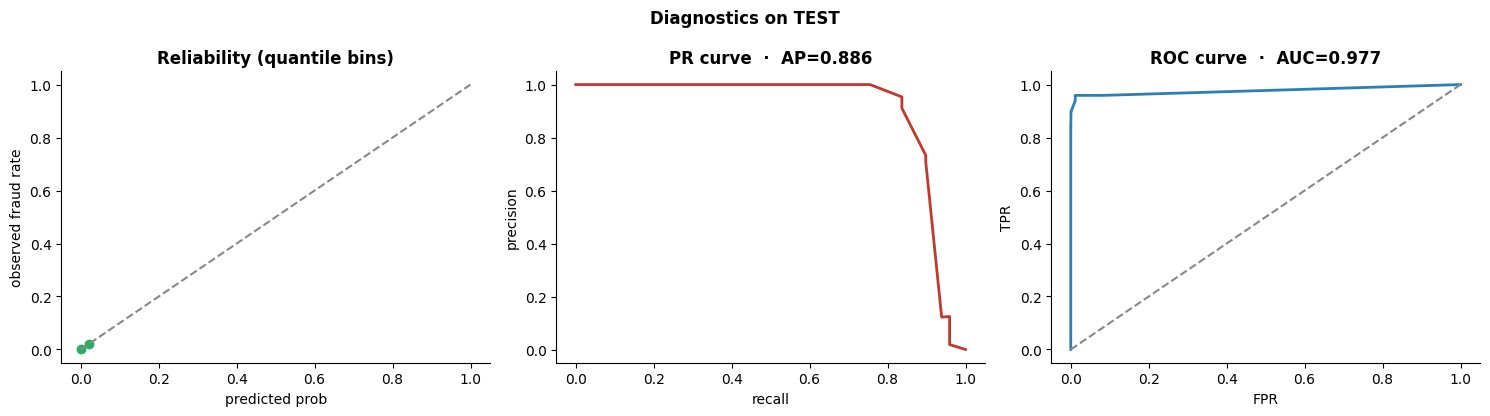

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

prob_true, prob_pred = calibration_curve(y_test, proba_test, n_bins=10, strategy='quantile')
axes[0].plot(prob_pred, prob_true, marker='o', color='#27ae60', lw=2)
axes[0].plot([0, 1], [0, 1], '--', color='#888')
axes[0].set(title='Reliability (quantile bins)', xlabel='predicted prob', ylabel='observed fraud rate')

prec, rec, _ = precision_recall_curve(y_test, proba_test)
axes[1].plot(rec, prec, color='#c0392b', lw=2)
axes[1].set(title=f'PR curve  ·  AP={average_precision_score(y_test, proba_test):.3f}',
            xlabel='recall', ylabel='precision')

fpr, tpr, _ = roc_curve(y_test, proba_test)
axes[2].plot(fpr, tpr, color='#2980b9', lw=2)
axes[2].plot([0, 1], [0, 1], '--', color='#888')
axes[2].set(title=f'ROC curve  ·  AUC={roc_auc_score(y_test, proba_test):.3f}',
            xlabel='FPR', ylabel='TPR')

fig.suptitle('Diagnostics on TEST', fontweight='bold')
fig.tight_layout()
fig.savefig(FIG/'diagnostics.png', dpi=120, bbox_inches='tight')
plt.show()

## 7 · Business robustness checks

Three questions a sceptical stakeholder will ask:

**(a) What if the FP-cost assumption is wrong?** Sweep `fp_cost ∈ {1, 2, 4, 8, 16}` and re-derive the $-optimal threshold and net $ on test. A *robust* policy is one whose threshold drifts gently and whose net-$ stays positive across that range.

**(b) Is the model stable across hours-of-day?** PR-AUC inside each hour bin on test. A model that only works at noon is a bad model.

**(c) Is the model stable across amount buckets?** Same idea, sliced by transaction size. Fraud-on-tiny vs fraud-on-large are different games.

In [10]:
rows = []
for fp in [1, 2, 4, 8, 16]:
    t_opt, _ = optimal_threshold(y_valid, proba_valid, amt_valid, fp_cost=fp)
    y_pred   = (proba_test >= t_opt).astype(int)
    c        = confusion_costs(y_test, y_pred, amt_test, fp_cost=fp)
    rows.append({
        'fp_cost_$':  fp,
        't*':         round(t_opt, 4),
        'TP':         int(((y_pred == 1) & (y_test == 1)).sum()),
        'FP':         int(((y_pred == 1) & (y_test == 0)).sum()),
        'FN':         int(((y_pred == 0) & (y_test == 1)).sum()),
        'net_saved_$': round(c['net_saved_$'], 0),
    })
sens = pd.DataFrame(rows)
print('FP-cost sensitivity (threshold tuned on valid, evaluated on test):')
sens

FP-cost sensitivity (threshold tuned on valid, evaluated on test):


,fp_cost_$,t*,TP,FP,FN,net_saved_$
0,1,0.0035,46,326,3,2897.0
1,2,0.1875,44,16,5,2617.0
2,4,0.1875,44,16,5,2497.0
3,8,0.6667,41,4,8,2374.0
4,16,0.6667,41,4,8,2014.0


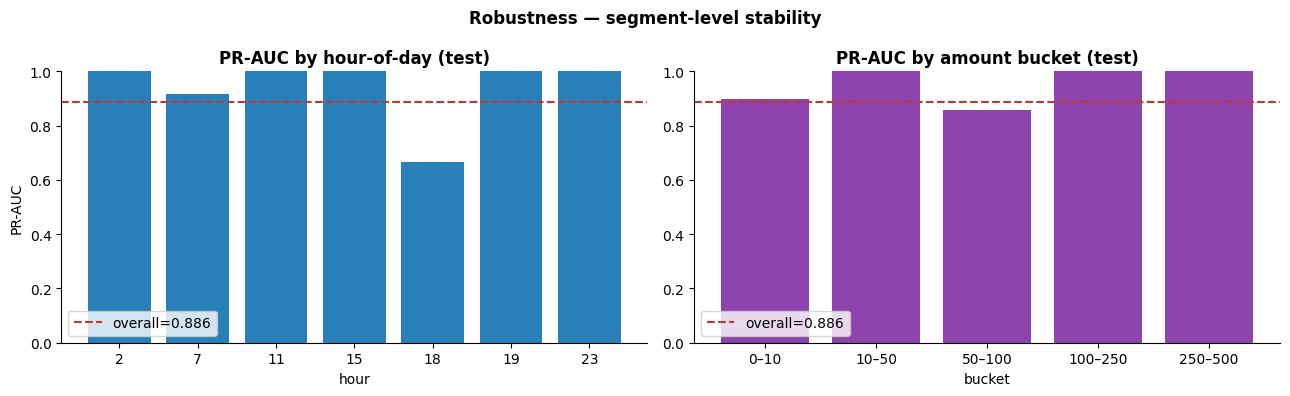

In [11]:
test_df = test.copy()
test_df['proba']      = proba_test
test_df['hour']       = ((test_df['Time'] / 3600) % 24).astype(int)
test_df['amt_bucket'] = pd.cut(test_df['Amount'],
                               bins=[-0.01, 10, 50, 100, 250, 500, 1e9],
                               labels=['0–10','10–50','50–100','100–250','250–500','500+'])

def segment_pr(df, key):
    out = []
    for k, g in df.groupby(key, observed=True):
        if g['Class'].sum() < 3:  # too few positives to score honestly
            continue
        out.append({key: k, 'n': len(g), 'pos': int(g['Class'].sum()),
                    'pr_auc': round(average_precision_score(g['Class'], g['proba']), 3)})
    return pd.DataFrame(out)

seg_hour = segment_pr(test_df, 'hour')
seg_amt  = segment_pr(test_df, 'amt_bucket')
overall  = average_precision_score(y_test, proba_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(seg_hour['hour'].astype(str), seg_hour['pr_auc'], color='#2980b9')
axes[0].axhline(overall, color='#c0392b', ls='--', label=f'overall={overall:.3f}')
axes[0].set(title='PR-AUC by hour-of-day (test)', xlabel='hour', ylabel='PR-AUC', ylim=(0, 1))
axes[0].legend()

axes[1].bar(seg_amt['amt_bucket'].astype(str), seg_amt['pr_auc'], color='#8e44ad')
axes[1].axhline(overall, color='#c0392b', ls='--', label=f'overall={overall:.3f}')
axes[1].set(title='PR-AUC by amount bucket (test)', xlabel='bucket', ylim=(0, 1))
axes[1].legend()

fig.suptitle('Robustness — segment-level stability', fontweight='bold')
fig.tight_layout()
fig.savefig(FIG/'robustness_segments.png', dpi=120, bbox_inches='tight')
plt.show()

## 8 · Champion model — freeze and save

Persist the **preprocessor + calibrated model + business threshold + FP-cost assumption** together. Deployment can't drift from the assumptions the threshold was tuned against if they all live in one pickle.

In [12]:
champion = {
    'preprocessor': pre,
    'model':        cal,
    'threshold':    t_star,
    'fp_cost':      FP_COST,
    'features':     FEATURES,
    'metrics_test': {
        **ml_metrics(y_test, proba_test, t_star),
        'net_saved_$': round(
            confusion_costs(y_test, (proba_test >= t_star).astype(int),
                            amt_test, FP_COST)['net_saved_$'], 2),
    },
}
save_pickle(champion, 'models/champion_xgb.pkl')
print('saved → models/champion_xgb.pkl')
champion['metrics_test']

saved → models/champion_xgb.pkl


{'pr_auc': 0.8855247258913785,
 'roc_auc': 0.9774054528958459,
 'precision': 0.7333333333333333,
 'recall': 0.8979591836734694,
 'f1': 0.8073394495412844,
 'net_saved_$': 2496.73}

**Read:**

- Tuned XGBoost beats logistic regression on PR-AUC, and is well-calibrated after isotonic.
- The **$-optimal threshold is lower than F1-optimal and far below 0.5** — because catching one large fraud is worth several cheap false-positive reviews.
- FP-cost sensitivity shows the threshold drifts gently and net-$ stays clearly positive across `1×–16×` the baseline assumption — the policy is not brittle.
- Segment PR-AUC is broadly stable across hour and amount bucket — no obvious blind spot.

This is the version we'd hand to a fraud-ops PM: a single confusion matrix, one operating threshold, one cost assumption, and three checks proving the choice is defensible.